In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pathlib import Path
from calculator import SeaIceCalc, Habitability, SST, SRD

In [3]:
file_indices = [0.5,0.75,1.0,1.25,1.5,1.75,2.0]
print(file_indices)

p = np.round(file_indices,3)
print(p)

[0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
[0.5  0.75 1.   1.25 1.5  1.75 2.  ]


In [4]:
file_template = "../pressure/{}.nc"
results = []

In [5]:
for idx in file_indices:
    fname = file_template.format(idx)

    # Ensure file exists
    if not Path(fname).exists():
        print(f"Warning: {fname} not found, skipping.")
        continue

    # Prepare containers for this file/run
    run = {
        "month": [],
        "ice_tot": [], "ice_nhem": [], "ice_shem": [],
        "sm_tot": [],  "sm_nhem": [],  "sm_shem": [],
        "st_tot": [],  "st_nhem": [],  "st_shem": [],
        "tsurf_tot": [], "tsurf_nhem": [], "tsurf_shem": [],
        "sst_tot": [], "sst_nhem": [], "sst_shem": [],
        "srd_tot": [], "srd_nhem": [], "srd_shem": []
    }
    
    # Open dataset and process
    with xr.open_dataset(fname) as ds:
        ds_crop = ds.sel(time=slice("2001-01-01", "2002-01-01"))
        monthly_data = ds_crop.groupby("time.month")
        months = np.array(sorted(monthly_data.groups.keys()), dtype=int)
        run["month"].append(months)

        for month, data in monthly_data:

            # Whole globe
            ice_frac = SeaIceCalc.ice_frac(data)[0]
            fraction_sm = Habitability.fraction(data, "sm")[0]
            fraction_st = Habitability.fraction(data, "st")[0]
            fraction_tsurf = Habitability.fraction(data, "tsurf")[0]
            sst_tot = SST.temp(data)
            srd_tot = SRD.srd_calc(data)[0]


            run["ice_tot"].append(ice_frac)
            run["sm_tot"].append(fraction_sm)
            run["st_tot"].append(fraction_st)
            run["tsurf_tot"].append(fraction_tsurf)
            run["sst_tot"].append(sst_tot)
            run["srd_tot"].append(srd_tot)

            # Northern hemisphere
            ice_n = SeaIceCalc.ice_frac(data, lat=slice(0,24))[0]
            sm_n = Habitability.fraction(data, "sm", lat=slice(0,24))[0]
            st_n = Habitability.fraction(data, "st", lat=slice(0,24))[0]
            tsurf_n = Habitability.fraction(data, "tsurf", lat=slice(0,24))[0]
            sst_n = SST.temp(data, lat=slice(0,24))
            srd_n = SRD.srd_calc(data, lat=slice(0,24))[0]

            run["ice_nhem"].append(ice_n)
            run["sm_nhem"].append(sm_n)
            run["st_nhem"].append(st_n)
            run["tsurf_nhem"].append(tsurf_n)
            run["sst_nhem"].append(sst_n)
            run["srd_nhem"].append(srd_n)

            # Southern hemisphere
            ice_s = SeaIceCalc.ice_frac(data, lat=slice(24,48))[0]
            sm_s = Habitability.fraction(data, "sm", lat=slice(24,48))[0]
            st_s = Habitability.fraction(data, "st", lat=slice(24,48))[0]
            tsurf_s = Habitability.fraction(data, "tsurf", lat=slice(24,48))[0]
            sst_s = SST.temp(data, lat=slice(24,48))
            srd_s = SRD.srd_calc(data, lat=slice(24,48))[0]
            run["ice_shem"].append(ice_s)
            run["sm_shem"].append(sm_s)
            run["st_shem"].append(st_s)
            run["tsurf_shem"].append(tsurf_s)
            run["sst_shem"].append(sst_s)
            run["srd_shem"].append(srd_s)

    # convert lists to numpy arrays (for math/plotting later)
    for k in run:
        if run[k] is None:
            continue
        if isinstance(run[k], list):
            run[k] = np.array(run[k]) 

    # Store results
    results.append({"file": fname, "data": run})


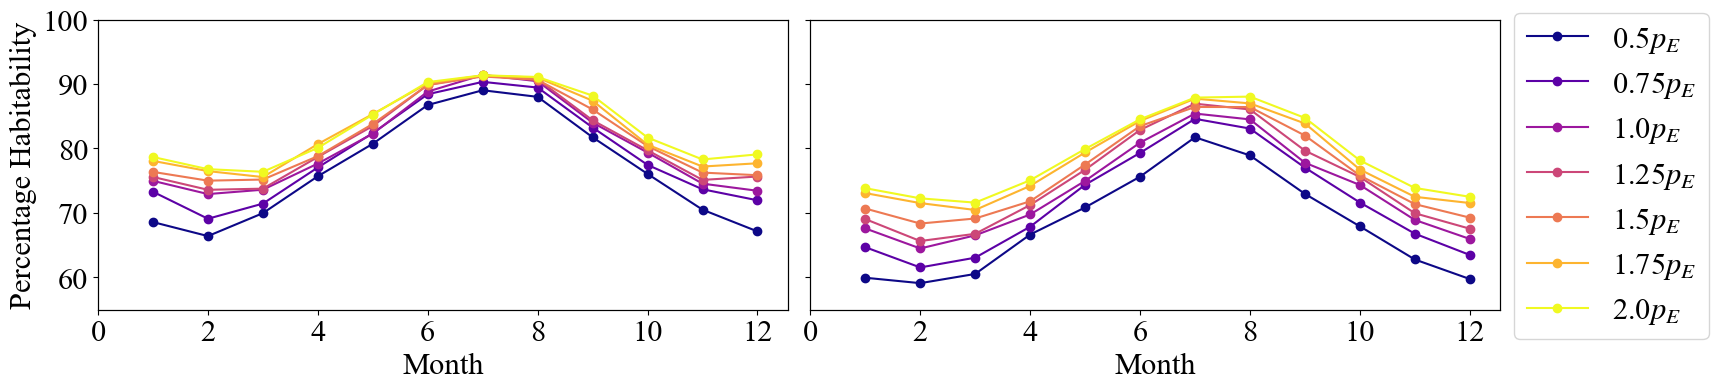

In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl

cmap = plt.cm.plasma   # choose colormap
norm = mpl.colors.Normalize(vmin=min(p), vmax=max(p))

# Global Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'

fig, ax = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

ax2_0 = ax[0].twinx()
ax2_1 = ax[1].twinx()

# -------- First plot --------
for r, f in zip(results,p):
    st = r["data"]["st_tot"]
    month = r["data"]["month"][0]
    color = cmap(norm(f))
    ax[0].plot(month, st, marker='o', label=f"{f}$p_E$",color=color)

ax[0].set_xlabel("Month", fontsize=22)
ax[0].set_ylabel("Percentage Habitability", fontsize=22)
ax[0].set_xticks([0,2,4,6,8,10,12])
# ax[0].text(0.98, 0.98, "(i)", transform=ax[0].transAxes,
#            ha="right", va="top", fontsize=16)

# -------- Second plot --------
for r, f in zip(results,p):
    tsurf = r["data"]["tsurf_tot"]
    month = r["data"]["month"][0]
    color = cmap(norm(f))
    ax[1].plot(month, tsurf, marker='o', label=f"{f}", color=color)


ax[1].set_xlabel("Month", fontsize=22)
ax[1].set_xticks([0,2,4,6,8,10,12])
# ax[1].text(0.98, 0.98, "(ii)", transform=ax[1].transAxes,
#            ha="right", va="top", fontsize=16)

# -------- Force Y limits AFTER plotting --------
for a in [ax[0], ax[1], ax2_0, ax2_1]:
    a.set_ylim(55, 100)

ax[0].set_yticks([60,70,80,90,100])

# Remove right-axis ticks (optional clean look)
ax2_0.set_yticks([])
ax2_1.set_yticks([])

ax[0].tick_params(axis='both', labelsize=22)
ax[1].tick_params(axis='both', labelsize=22)

# -------- Legend closer --------
handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc="lower left",
    bbox_to_anchor=(0.94, 0.1),
    fontsize=22
)


plt.tight_layout(rect=[0, 0, 0.95, 1])
# plt.savefig("rot_season_hab.png", dpi=300, bbox_inches='tight')
plt.show()

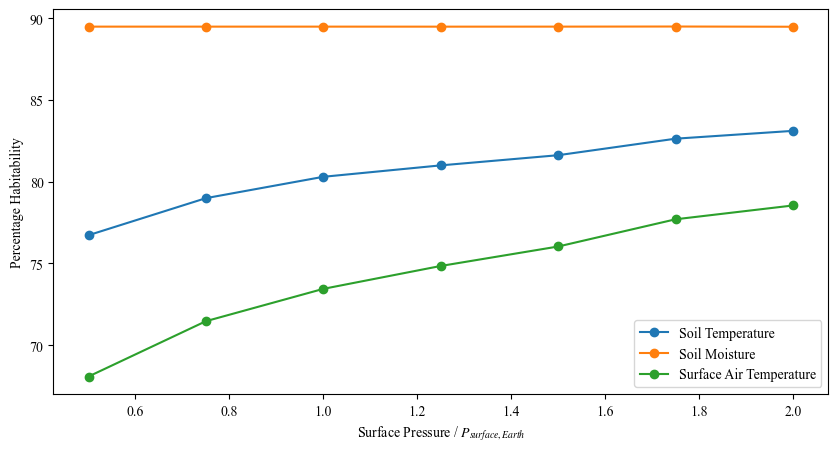

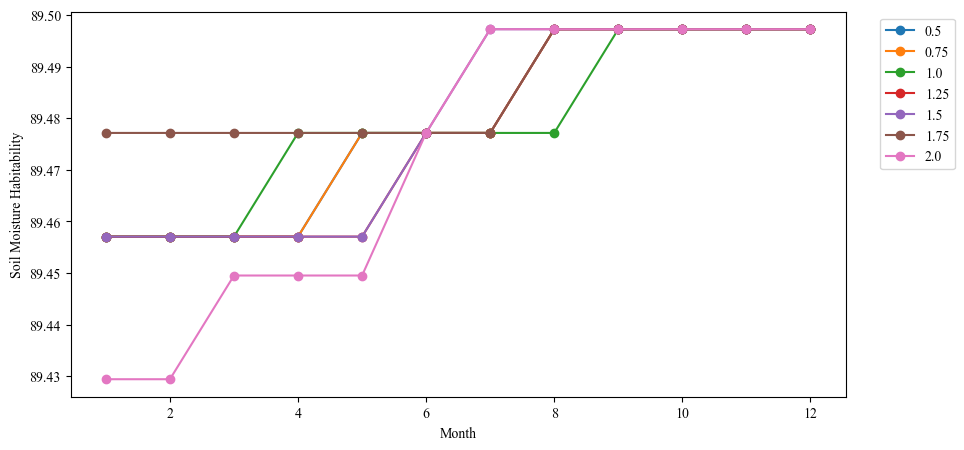

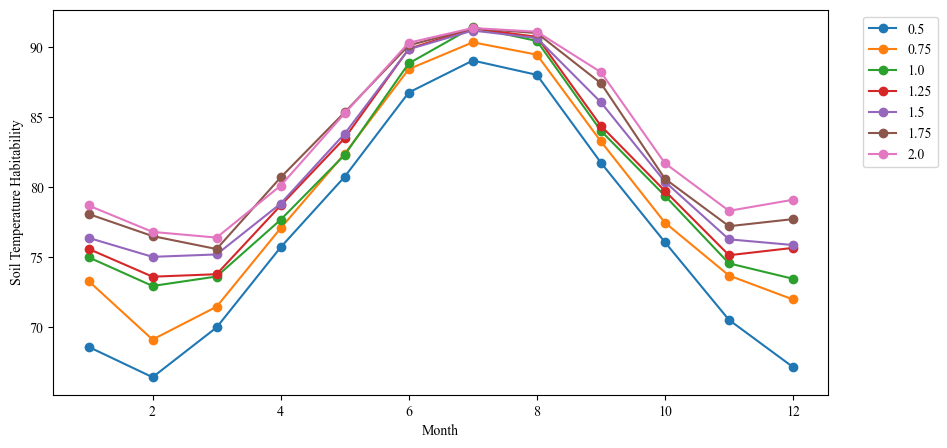

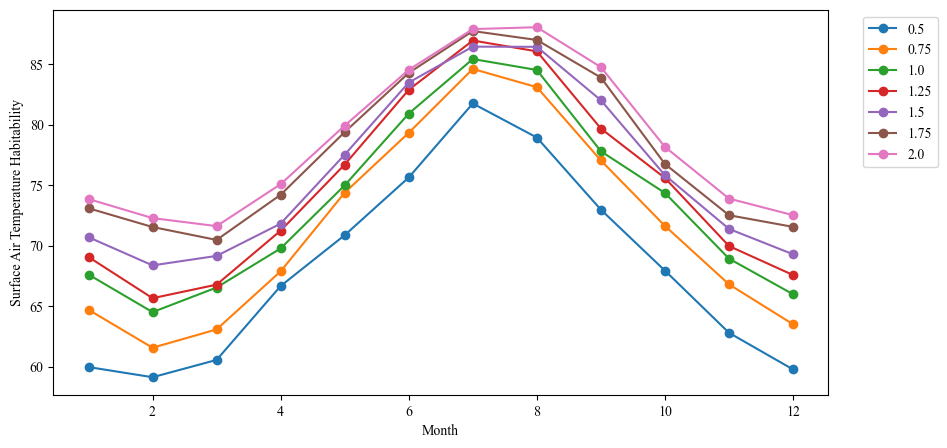

In [7]:
fig = plt.figure(figsize=(10, 5))
y_sm = []
y_st = []
y_tsurf = []
x = []
for r, f in zip(results, p):
    st = r["data"]["st_tot"].mean()
    sm = r["data"]["sm_tot"].mean()
    tsurf = r["data"]["tsurf_tot"].mean()
    x.append(f)
    y_st.append(st)
    y_sm.append(sm)
    y_tsurf.append(tsurf)

plt.plot(x, y_st, marker='o', label="Soil Temperature")
plt.plot(x, y_sm, marker='o', label="Soil Moisture")
plt.plot(x, y_tsurf, marker='o', label="Surface Air Temperature")
plt.xlabel("Surface Pressure / $P_{surface, Earth}$")
plt.ylabel("Percentage Habitability")
plt.legend(loc="lower right")
plt.show()


fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, p):
    sm = r["data"]["sm_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, sm, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Soil Moisture Habitability")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, p):
    st = r["data"]["st_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, st, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Soil Temperature Habitability")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, p):
    tsurf = r["data"]["tsurf_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, tsurf, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Surface Air Temperature Habitability")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

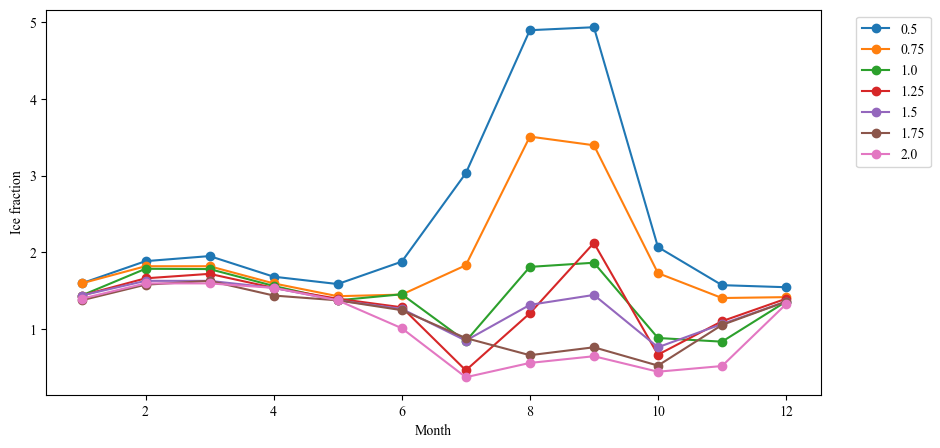

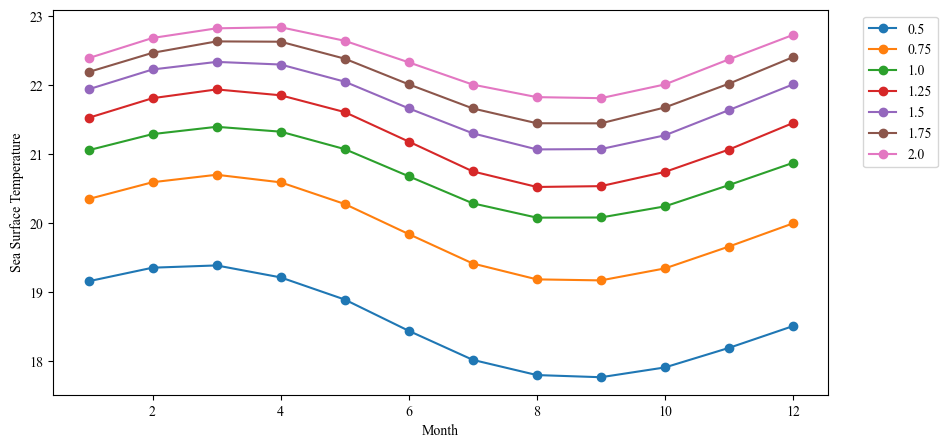

In [8]:
fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, p):
    ice = r["data"]["ice_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, ice, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Ice fraction")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, p):
    sst = r["data"]["sst_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, sst, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Sea Surface Temperature")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

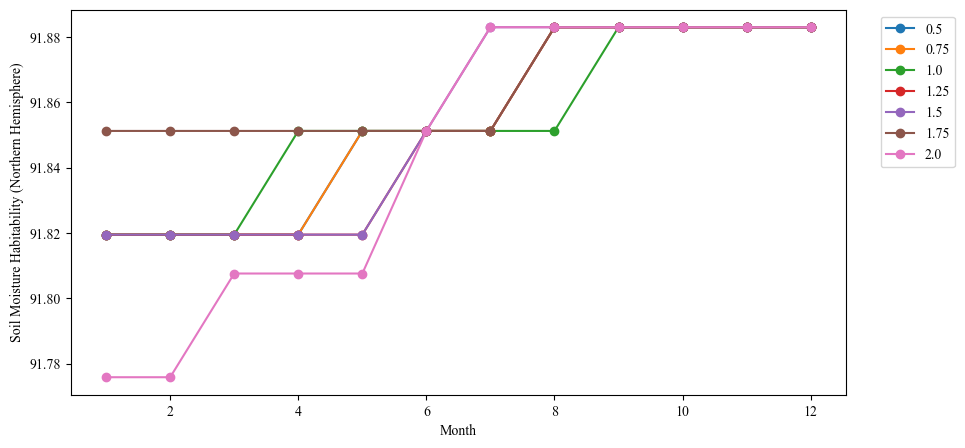

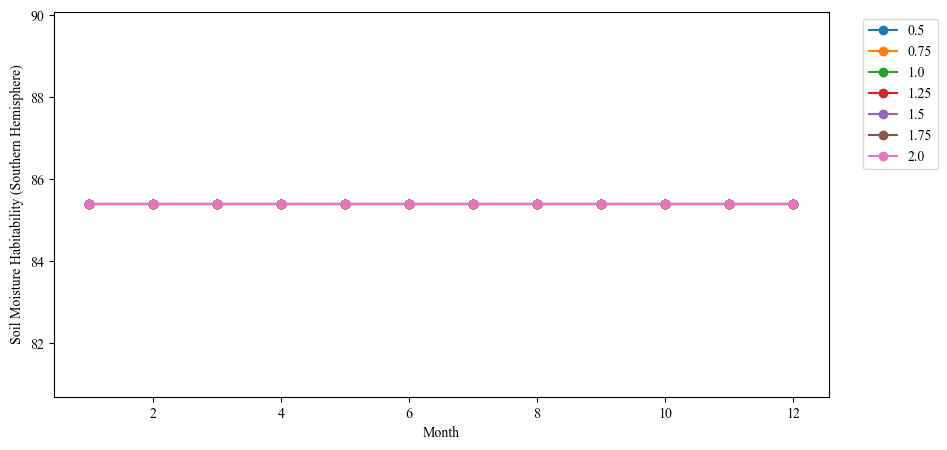

In [9]:
# Check habitability in different hemispheres for soil moisture 

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, p):
    sm = r["data"]["sm_nhem"]
    month = r["data"]["month"][0]
    plt.plot(month, sm, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Soil Moisture Habitability (Northern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, p):
    sm = r["data"]["sm_shem"]
    month = r["data"]["month"][0]
    # plt.plot(month, sm, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, sm, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Soil Moisture Habitability (Southern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

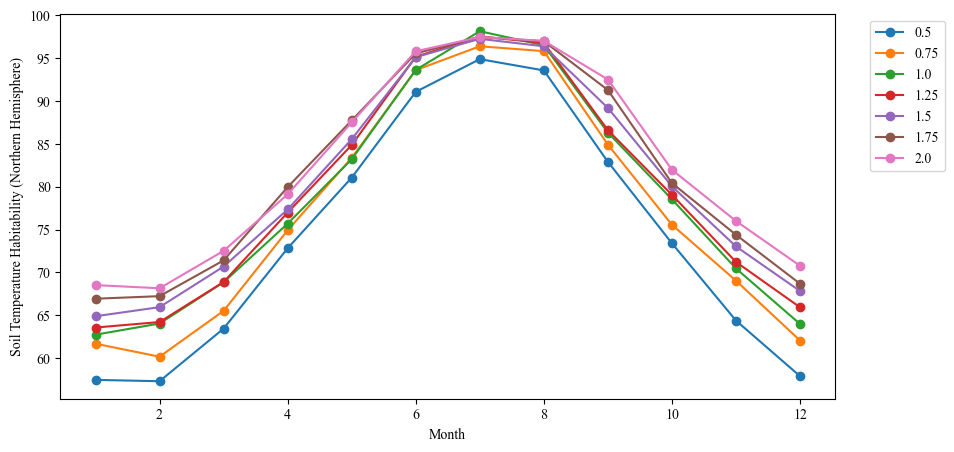

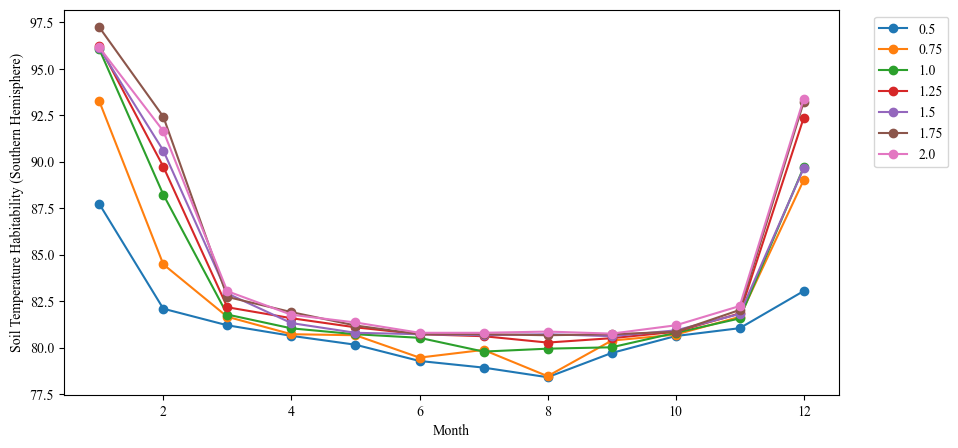

In [10]:
fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, p):
    st = r["data"]["st_nhem"]
    month = r["data"]["month"][0]
    # plt.plot(month, st, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, st, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Soil Temperature Habitability (Northern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, p):
    st = r["data"]["st_shem"]
    month = r["data"]["month"][0]
    plt.plot(month, st, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Soil Temperature Habitability (Southern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

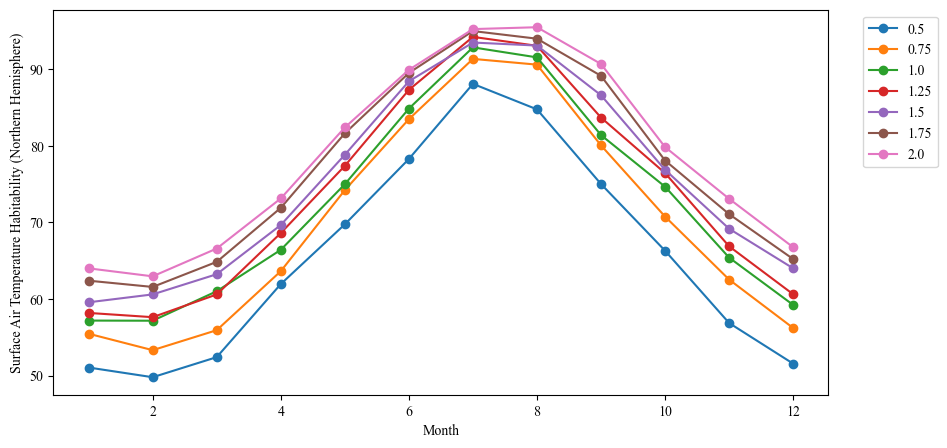

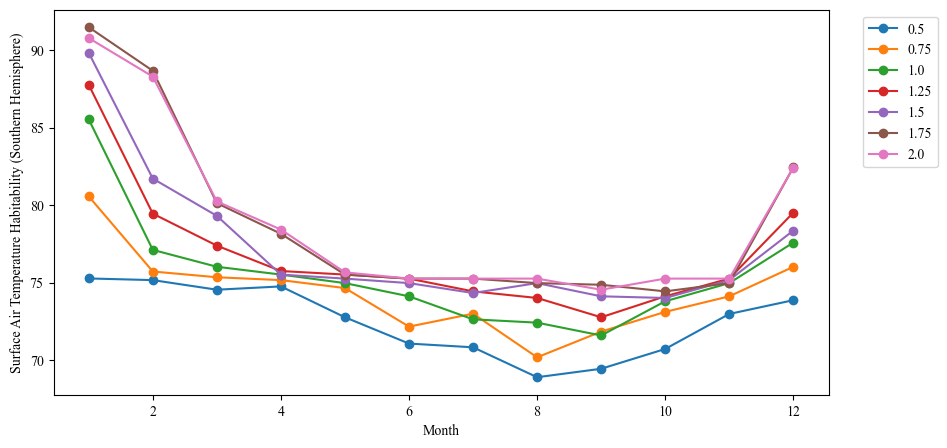

In [11]:
fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, p):
    tsurf = r["data"]["tsurf_nhem"]
    month = r["data"]["month"][0]
    # plt.plot(month, st, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, tsurf, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Surface Air Temperature Habitability (Northern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, p):
    tsurf = r["data"]["tsurf_shem"]
    month = r["data"]["month"][0]
    plt.plot(month, tsurf, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Surface Air Temperature Habitability (Southern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

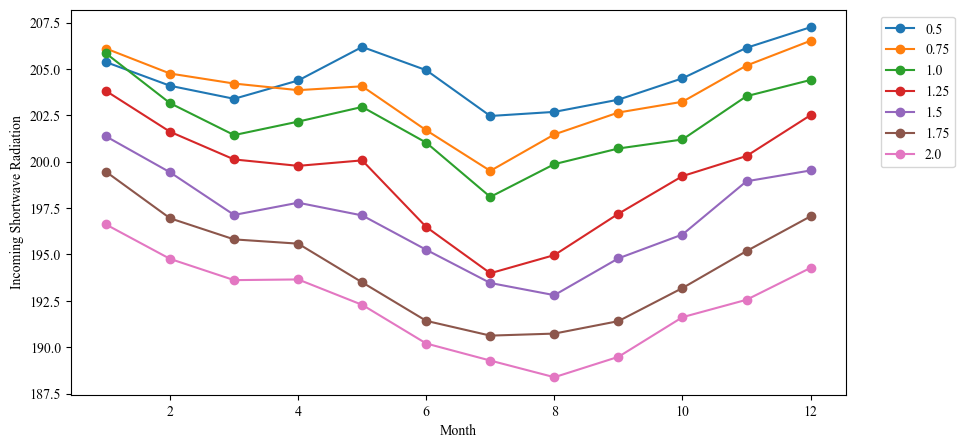

In [12]:
fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, p):
    srd = r["data"]["srd_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, srd, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel(f"Incoming Shortwave Radiation")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

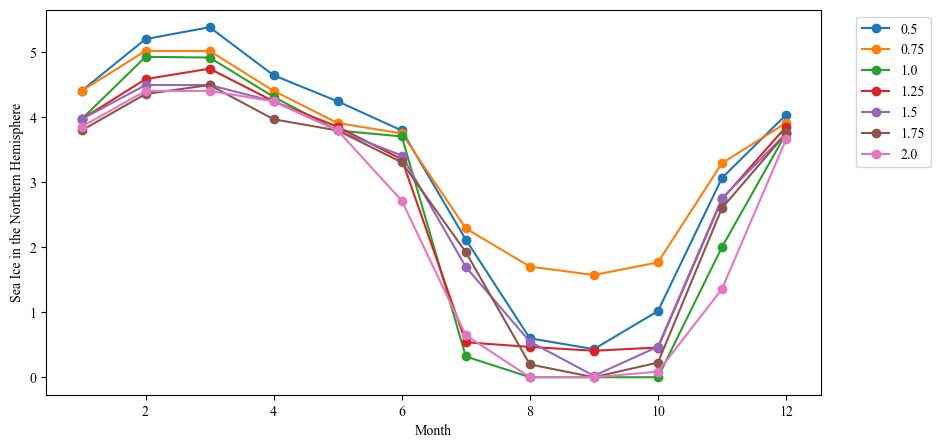

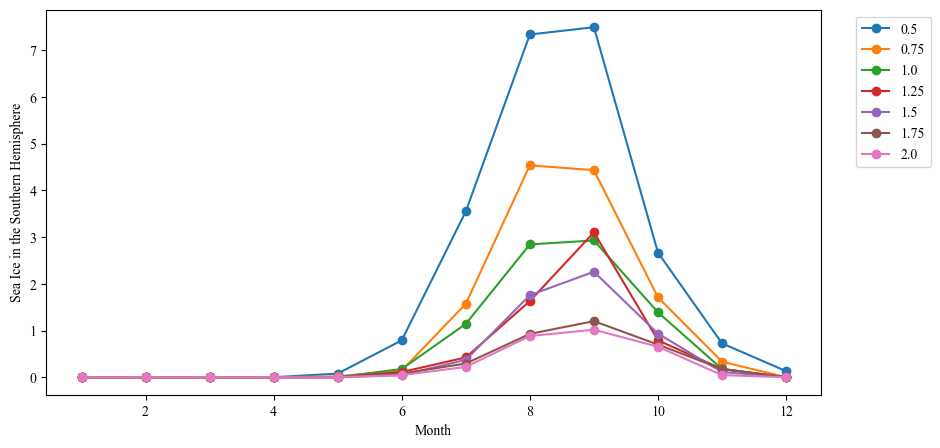

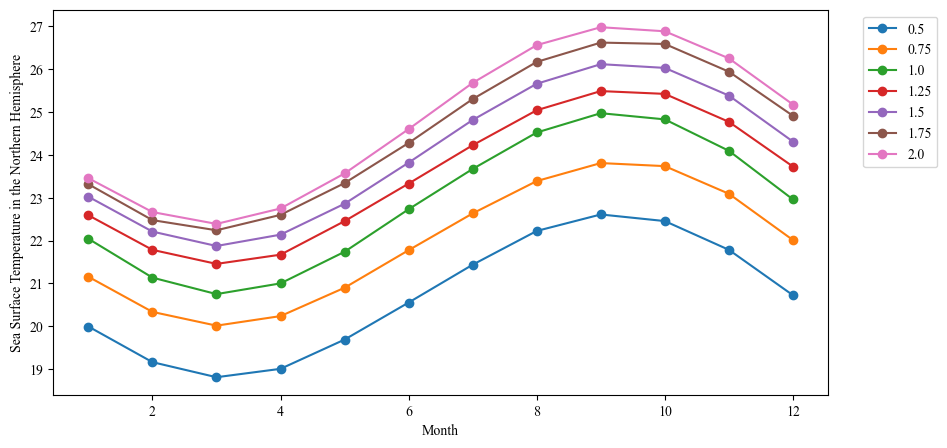

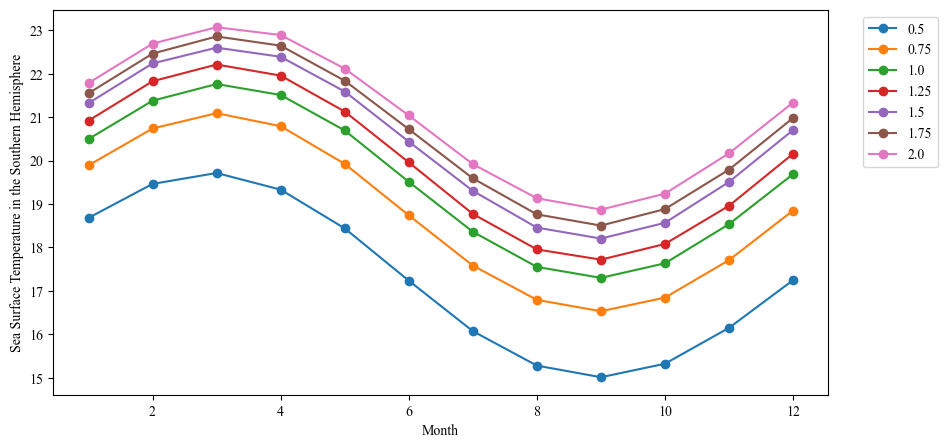

In [13]:
fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, p):
    st = r["data"]["ice_nhem"]
    plt.plot(month, st, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Sea Ice in the Northern Hemisphere")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, p):
    month = r["data"]["month"][0]
    st = r["data"]["ice_shem"]
    plt.plot(month, st, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Sea Ice in the Southern Hemisphere")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, p):
    st = r["data"]["sst_nhem"]
    month = r["data"]["month"][0]
    plt.plot(month, st, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Sea Surface Temperature in the Northern Hemisphere")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, p):
    month = r["data"]["month"][0]
    st = r["data"]["sst_shem"]
    plt.plot(month, st, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Sea Surface Temperature in the Southern Hemisphere")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()